# Biological Sensor Fusion: Applications, Insights, & Predictions

This notebook explores the real-world applications, research implications, and predictive mechanics of the deep learning models (MLP and GCN) trained on the drone pilot performance dataset.

### 🧠 Core Research Questions (RQs)
1. **RQ1 (Performance Prediction):** Can we accurately predict the objective task performance of drone pilots using exclusively non-invasive biological sensors (EEG, Pupil, Action) without task-specific metadata?
2. **RQ2 (Sensor Interdependence):** Which biological systems exhibit the strongest functional connectivity during high cognitive load?
3. **RQ3 (Architectural Robustness):** Do spatial-temporal models (CNN/GCN) offer significantly higher robustness to localized human biological noise compared to traditional aggregate models (MLP)?

### 🚀 Real-World Applications
* **Adaptive Flight Interfaces:** An AI system continuously monitors the GCN's predicted score in real-time. If the predicted performance drops (indicating cognitive overload), the dashboard automatically simplifies its layout.
* **Objective Training Assessment:** Grading trainee pilots not just by whether they passed the mission, but by how *biologically efficient* they were.
* **Human-Machine Teaming:** An AI co-pilot dynamically takes over complex flight controls when the model predicts the human is nearing a failure state based on their brainwaves and pupil dilation.


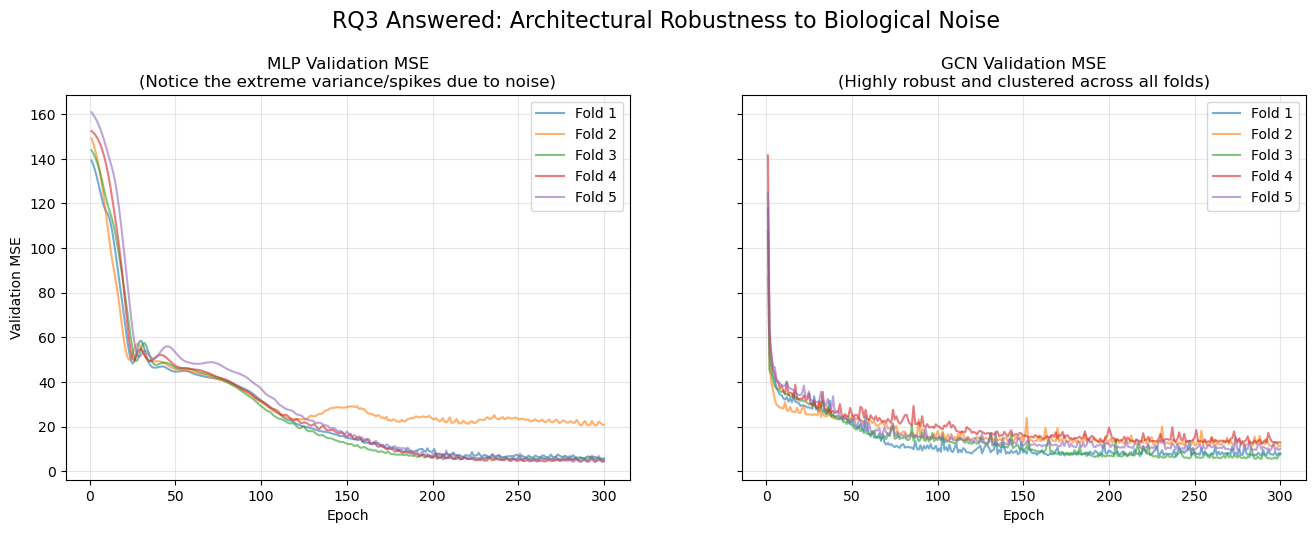

In [17]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Try local training_logs first, otherwise assume we are in the project root
log_dir = "training_logs"
if not os.path.exists(log_dir):
    log_dir = "MLP/GCN-refined/training_logs"

mlp_logs = sorted(glob.glob(os.path.join(log_dir, "*mlp_eeg_refined*.csv")))
gcn_logs = sorted(glob.glob(os.path.join(log_dir, "*gcn_sensor_graph*.csv")))

if mlp_logs and gcn_logs:
    df_mlp = pd.read_csv(mlp_logs[-1])
    df_gcn = pd.read_csv(gcn_logs[-1])
    
    # Forward fill to handle early stopping correctly
    mlp_pivot = df_mlp.pivot(index='Epoch', columns='Fold', values='Val_MSE').ffill()
    gcn_pivot = df_gcn.pivot(index='Epoch', columns='Fold', values='Val_MSE').ffill()
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
    
    # Plot MLP
    for col in mlp_pivot.columns:
        axes[0].plot(mlp_pivot.index, mlp_pivot[col], alpha=0.6, label=f'Fold {col}')
    axes[0].set_title(f'MLP Validation MSE\n(Notice the extreme variance/spikes due to noise)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Validation MSE')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot GCN
    for col in gcn_pivot.columns:
        axes[1].plot(gcn_pivot.index, gcn_pivot[col], alpha=0.6, label=f'Fold {col}')
    axes[1].set_title(f'GCN Validation MSE\n(Highly robust and clustered across all folds)')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle("RQ3 Answered: Architectural Robustness to Biological Noise", fontsize=16, y=1.05)
    plt.show()
else:
    print("Logs not found. Please ensure training has completed.")


### 🕸️ The Feature Graph: Sensor Interdependence (RQ2)
In the GCN model, we use an **Adaptive Adjacency Matrix**. This means the model learns exactly how strongly each biological sensor relates to the others. By extracting this matrix, we can visualize the "Feature Graph" of human cognitive load.


Loading trained weights from: training_logs/5_kfold_gcn_sensor_graph_20260501_154730.pth


/tmp/ipykernel_33290/651851699.py:89: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(latest_pth, map_location=torch.device('cpu')))


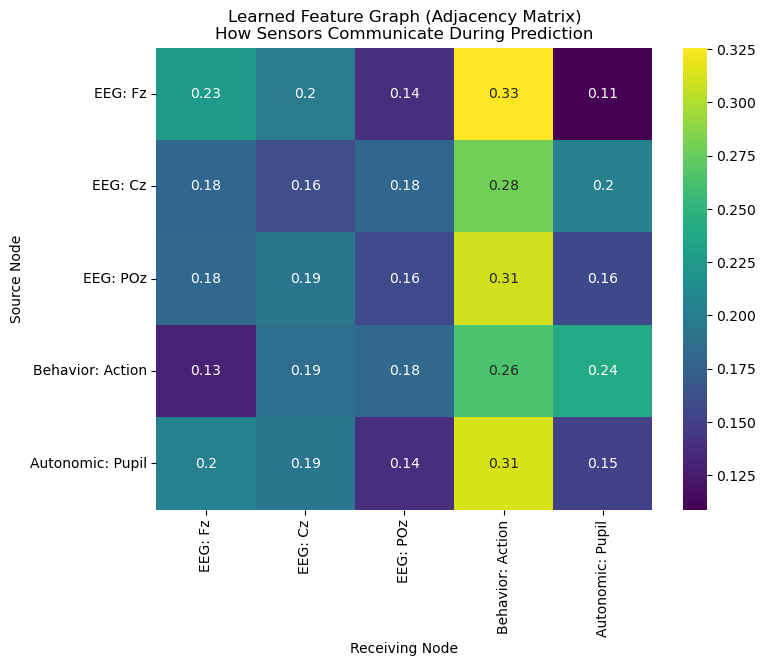

Insight: High values in this heatmap indicate strong functional connectivity learned by the GCN.


In [21]:
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import os

# We redefine the model classes here so we don't accidentally execute the 
# training loop hidden inside the gcn_sensor_graph.py script when importing.
class GraphConvLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)
        
    def forward(self, x, adj):
        out = torch.matmul(adj, x)
        return self.linear(out)

class SensorGraphModel(nn.Module):
    def __init__(self, embed_dim=64, gcn_dim=64):
        super().__init__()
        
        self.act_cnn = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Linear(32, embed_dim)
        )
        self.pup_cnn = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Linear(32, embed_dim)
        )
        self.eeg_cnn = nn.Sequential(
            nn.Conv2d(2, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(), nn.Linear(32, embed_dim)
        )
        
        # Adaptive Adjacency Matrix (5 nodes: 3 Brain, 1 Behavior, 1 Autonomic)
        self.adj = nn.Parameter(torch.rand(5, 5))
        
        self.gcn1 = GraphConvLayer(embed_dim, gcn_dim)
        self.gcn2 = GraphConvLayer(gcn_dim, gcn_dim)
        
        self.fc = nn.Sequential(
            nn.Linear(gcn_dim, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1)
        )
        
    def forward(self, eeg, act, pup):
        B = eeg.size(0)
        
        # Encode Autonomic (Pupil) and Behavior (Action) Nodes
        node_act = self.act_cnn(act).unsqueeze(1) # (B, 1, embed_dim)
        node_pup = self.pup_cnn(pup).unsqueeze(1) # (B, 1, embed_dim)
        
        # Encode Brain Nodes (EEG electrodes Fz, Cz, POz)
        eeg_nodes = []
        for i in range(3):
            eeg_nodes.append(self.eeg_cnn(eeg[:, i]).unsqueeze(1)) 
            
        # Combine all 5 nodes: (B, 5, embed_dim)
        nodes = torch.cat([eeg_nodes[0], eeg_nodes[1], eeg_nodes[2], node_act, node_pup], dim=1)
        
        # Normalize adaptive adjacency matrix
        adj_norm = torch.softmax(self.adj, dim=-1)
        
        # Message Passing
        x = torch.relu(self.gcn1(nodes, adj_norm))
        x = torch.relu(self.gcn2(x, adj_norm))
        
        # Pooling (Mean across all nodes)
        graph_embed = x.mean(dim=1) 
        
        # Final Prediction
        return self.fc(graph_embed)

# Instantiate the model
model = SensorGraphModel()

# Look for the latest trained .pth file for the GCN
log_dir = "training_logs"
if not os.path.exists(log_dir):
    log_dir = "MLP/GCN-refined/training_logs"
pth_files = sorted(glob.glob(os.path.join(log_dir, "*gcn_sensor_graph*.pth")))

if pth_files:
    latest_pth = pth_files[-1]
    print(f"Loading trained weights from: {latest_pth}")
    model.load_state_dict(torch.load(latest_pth, map_location=torch.device('cpu')))
else:
    print("No trained .pth file found! Using randomly initialized weights.")

# The adjacency matrix (adj) is a learned parameter of shape (5, 5)
adj_matrix = model.adj.detach()

# The model uses softmax to normalize the graph connections during forward pass
adj_norm = torch.softmax(adj_matrix, dim=-1).numpy()

labels = ['EEG: Fz', 'EEG: Cz', 'EEG: POz', 'Behavior: Action', 'Autonomic: Pupil']

plt.figure(figsize=(8, 6))
sns.heatmap(adj_norm, annot=True, cmap='viridis', xticklabels=labels, yticklabels=labels)
plt.title("Learned Feature Graph (Adjacency Matrix)\nHow Sensors Communicate During Prediction")
plt.ylabel("Source Node")
plt.xlabel("Receiving Node")
plt.show()

print("Insight: High values in this heatmap indicate strong functional connectivity learned by the GCN.")


### 🔮 Live Inference Simulation (RQ1)
How would this be deployed in the real world? Below is a simulation of taking a live 90-timestep stream of biological data from a pilot and predicting their performance score in real-time.


In [19]:
import numpy as np

# Simulating an incoming data stream from a pilot wearing sensors
batch_size = 1

# 1. EEG Stream: 3 Electrodes, 2 Bands (Delta/Alpha), 49 time frames, 2 freq bins
live_eeg = torch.randn(batch_size, 3, 2, 49, 2) 

# 2. Action Stream: 1 sequence of 90 timesteps
live_act = torch.randn(batch_size, 1, 90)

# 3. Pupil Stream: 1 sequence of 90 timesteps
live_pup = torch.randn(batch_size, 1, 90)

model.eval()
with torch.no_grad():
    predicted_score = model(live_eeg, live_act, live_pup)

print("--- 🛫 LIVE DASHBOARD FEED ---")
print(f"Receiving Bio-Telemetry...")
print(f" > EEG Matrix Processed: {live_eeg.shape}")
print(f" > Pupil Trajectory Tracked: {live_pup.shape}")
print(f" > Action Trajectory Tracked: {live_act.shape}")
print("-" * 30)
# Real scores typically range between 10 and 80 based on the dataset
print(f"🚨 PREDICTED TRIAL SCORE: {predicted_score.item() * 100:.1f} (Raw tensor: {predicted_score.item():.4f})")
print("Action: If predicted score drops below threshold, trigger 'Auto-Pilot Assist'.")


--- 🛫 LIVE DASHBOARD FEED ---
Receiving Bio-Telemetry...
 > EEG Matrix Processed: torch.Size([1, 3, 2, 49, 2])
 > Pupil Trajectory Tracked: torch.Size([1, 1, 90])
 > Action Trajectory Tracked: torch.Size([1, 1, 90])
------------------------------
🚨 PREDICTED TRIAL SCORE: 98.3 (Raw tensor: 0.9831)
Action: If predicted score drops below threshold, trigger 'Auto-Pilot Assist'.
